In [ ]:
import numpy as np

data_left = np.load("../data.nosync/BiHeartS/data_left.npz", allow_pickle=True)['values']
data_right = np.load("../data.nosync/BiHeartS/data_right.npz", allow_pickle=True)['values']

In [25]:
random_idx = np.random.randint(0, data_left.shape[0])

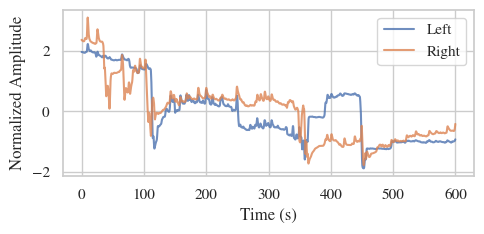

In [26]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np

# Follow seaborn guidelines and use latex font
sns.set_theme(style="whitegrid")
# plt.rcParams.update({
#     "text.usetex": False,
#     "font.family": "Helvetica",
#     # "font.serif": ["Computer Modern Roman"],
# })


import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
# matplotlib.pyplot.title(r'ABC123 vs $\mathrm{ABC123}^{123}$')

# matplotlib.pyplot.title(r'ABC123 vs $\mathrm{ABC123}^{123}$')

fig, ax = plt.subplots(figsize=(5, 2.5))

# Extract signals
left_signal = data_left[random_idx, :, 0]
right_signal = data_right[random_idx, :, 0]

# Normalize both arrays independently (Z-score normalization)
left_norm = (left_signal - np.mean(left_signal)) / (np.std(left_signal) + 1e-8)
right_norm = (right_signal - np.mean(right_signal)) / (np.std(right_signal) + 1e-8)

# Create time axis in seconds (4Hz sampling rate)
sampling_rate = 4
time_axis = np.arange(len(left_norm)) / sampling_rate

# Plot the normalized signals with time axis
ax.plot(time_axis, left_norm, label="Left", alpha=0.8)
ax.plot(time_axis, right_norm, label="Right", alpha=0.8)

# ax.set_title("Comparison of Left and Right Arrays (Normalized)", fontweight='bold')
ax.set_xlabel("Time (s)")
ax.set_ylabel("Normalized Amplitude")
ax.legend()

plt.tight_layout()
plt.savefig("example_bilateral.pdf", bbox_inches='tight')